### Giraffe deep learning model with DeepChess' Feature Encoding

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import random


### 1. Data Preparation

In [ ]:
# Load dataset
#data = np.load("./dataset/bitboard_stockfish_dataset.npz")
#data = np.load("./bitboard_stockfish_dataset.npz") # for google colab
data = np.load("/kaggle/input/integrated-dataset/bitboard_stockfish_dataset.npz") # for kaggle
X, y = data["features"], data["labels"]


# Split dataset into training (60%), validation (20%), and test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=True)

# Convert data to PyTorch tensors
train_tensor_X = torch.tensor(X_train, dtype=torch.float32)
train_tensor_y = torch.tensor(y_train, dtype=torch.float32)

val_tensor_X = torch.tensor(X_val, dtype=torch.float32)
val_tensor_y = torch.tensor(y_val, dtype=torch.float32)

test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_tensor_y = torch.tensor(y_test, dtype=torch.float32)

# Wrap them in TensorDataset
train_dataset = TensorDataset(train_tensor_X, train_tensor_y)
val_dataset = TensorDataset(val_tensor_X, val_tensor_y)
test_dataset = TensorDataset(test_tensor_X, test_tensor_y)

# Create DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# Get a batch from each DataLoader and print shapes
train_features, train_labels = next(iter(train_loader))
val_features, val_labels = next(iter(val_loader))
test_features, test_labels = next(iter(test_loader))

print(f"Train batch shape: Features {train_features.shape}, Labels {train_labels.shape}")
print(f"Validation batch shape: Features {val_features.shape}, Labels {val_labels.shape}")
print(f"Test batch shape: Features {test_features.shape}, Labels {test_labels.shape}")


Train batch shape: Features torch.Size([512, 773]), Labels torch.Size([512])
Validation batch shape: Features torch.Size([512, 773]), Labels torch.Size([512])
Test batch shape: Features torch.Size([512, 773]), Labels torch.Size([512])


### Integrated Model

In [ ]:
class Pos2Vec(nn.Module):
    def __init__(self, input_size, output_size):
        super(Pos2Vec, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, output_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(output_size, input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


class FinalPos2Vec(nn.Module):
    def __init__(self, layer_sizes):
        super(FinalPos2Vec, self).__init__()
        self.encoders = nn.ModuleList([
            Pos2Vec(layer_sizes[i], layer_sizes[i+1]) for i in range(len(layer_sizes)-1)
        ])

    def forward(self, x):
        for encoder in self.encoders:
            x, _ = encoder(x) # only require encoded output
        return x # final encoded representation


class IntegratedModel(nn.Module):
    def __init__(self, pos2vec):
        super(IntegratedModel, self).__init__()
        self.pos2vec = pos2vec # Pos2Vec autoencoder
        for param in self.pos2vec.parameters(): # unfreeze autoencoder
            param.requires_grad = True
        self.nn_layers = nn.Sequential(
            nn.Linear(100, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1),
            nn.Tanh() # output between -1 and 1
        )

    def forward(self, x):
        embedded_feat = self.pos2vec(x) # encode position
        output = self.nn_layers(embedded_feat)
        return output

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100, device="cuda"):
    model.to(device)
    best_val_loss = float("inf")
    train_losses = []
    val_losses = []

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5)
    
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, targets)
                running_val_loss += loss.item()
        
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "./integrated_model.pth") # for kaggle
            #torch.save(model.state_dict(), "./models/integrated_model.pth")

    return train_losses, val_losses

In [12]:
layer_sizes = [773, 600, 400, 200, 100]
pos2vec = FinalPos2Vec(layer_sizes)
#pos2vec.load_state_dict(torch.load("./models/Pos2Vec_autoencoder.pth", weights_only=True))
pos2vec.load_state_dict(torch.load("/kaggle/input/pos2vec_autoencoder/pytorch/default/1/Pos2Vec_autoencoder.pth", weights_only=True)) # for kaggle
integrated_model = IntegratedModel(pos2vec)

criterion = nn.MSELoss()
optimizer = optim.Adam(integrated_model.parameters(), lr=0.001, weight_decay=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses, val_losses = train_model(integrated_model, train_loader, val_loader, criterion, optimizer, num_epochs=100, device=device)


Epoch [1/100] - Train Loss: 0.1180 - Val Loss: 0.0974
Epoch [2/100] - Train Loss: 0.0945 - Val Loss: 0.0865
Epoch [3/100] - Train Loss: 0.0826 - Val Loss: 0.0811
Epoch [4/100] - Train Loss: 0.0758 - Val Loss: 0.0770
Epoch [5/100] - Train Loss: 0.0716 - Val Loss: 0.0752
Epoch [6/100] - Train Loss: 0.0688 - Val Loss: 0.0732
Epoch [7/100] - Train Loss: 0.0669 - Val Loss: 0.0734
Epoch [8/100] - Train Loss: 0.0653 - Val Loss: 0.0725
Epoch [9/100] - Train Loss: 0.0644 - Val Loss: 0.0721
Epoch [10/100] - Train Loss: 0.0634 - Val Loss: 0.0726
Epoch [11/100] - Train Loss: 0.0626 - Val Loss: 0.0723
Epoch [12/100] - Train Loss: 0.0622 - Val Loss: 0.0721
Epoch [13/100] - Train Loss: 0.0613 - Val Loss: 0.0716
Epoch [14/100] - Train Loss: 0.0610 - Val Loss: 0.0716
Epoch [15/100] - Train Loss: 0.0606 - Val Loss: 0.0711
Epoch [16/100] - Train Loss: 0.0603 - Val Loss: 0.0717
Epoch [17/100] - Train Loss: 0.0600 - Val Loss: 0.0721
Epoch [18/100] - Train Loss: 0.0597 - Val Loss: 0.0711
Epoch [19/100] - Tr

In [ ]:
def plot_training_curve(train_losses, val_losses):
    epochs = np.arange(1, len(train_losses) + 1)
    best_epoch = np.argmin(val_losses) + 1 # get the epoch with the lowest validation loss
    best_val_loss = val_losses[best_epoch - 1]
    best_train_loss = train_losses[best_epoch - 1]

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    
    # Mark the best epoch with a red vertical line
    plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best Epoch: {best_epoch}")

    # Annotate the best epoch's loss values
    plt.text(best_epoch, best_val_loss, 
             f"Val Loss: {best_val_loss:.4f}\nTrain Loss: {best_train_loss:.4f}", 
             verticalalignment="bottom", horizontalalignment="right", 
             fontsize=10, color="red", bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss Curve")
    plt.legend()
    plt.show()


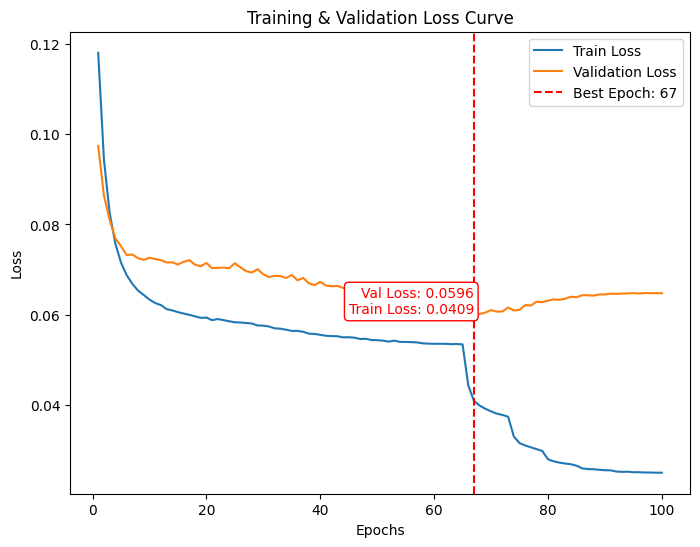

In [21]:
plot_training_curve(train_losses, val_losses)

In [22]:
def test_model(model, test_loader):    
    y_true = []
    y_pred = []
    test_loss = 0
    criterion = torch.nn.MSELoss()

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X).squeeze()
            loss = criterion(y_hat, y)
            test_loss += loss.item()

            y_true.append(y.cpu().numpy())
            y_pred.append(y_hat.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)

    # Flatten the list of true and predicted values
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    # Calculate RMSE
    rmse = np.sqrt(avg_test_loss)

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot predictions vs actual values
    plt.figure(figsize=(8, 6))

    sample_size = 5000
    indices = random.sample(range(len(y_true)), min(sample_size, len(y_true)))
    y_true_sampled = np.array(y_true)[indices]
    y_pred_sampled = np.array(y_pred)[indices]
    
    plt.scatter(y_true_sampled, y_pred_sampled, alpha=0.5, color='blue', label="Predictions")
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2, label="Perfect Fit")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predictions vs Actual Values')
    plt.legend()
    plt.show()

    return rmse

Test Loss: 0.0600
RMSE: 0.2449


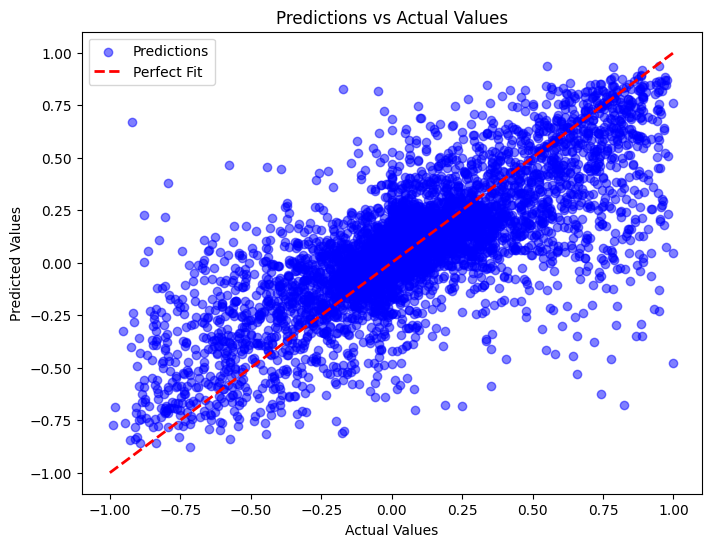

In [25]:
layer_sizes = [773, 600, 400, 200, 100]
pos2vec = FinalPos2Vec(layer_sizes)
model = IntegratedModel(pos2vec).to(device)
#model.load_state_dict(torch.load("./models/integrated_model.pth", weights_only=True))
model.load_state_dict(torch.load("./integrated_model.pth", weights_only=True)) # for kaggle

model.eval()
rmse = test_model(model, test_loader)